# Este set de datos de Our World in Data titulado "Average learning outcomes by total education expenditure per capita" presenta una relación entre:

## 1. Resultados promedio de aprendizaje (Average learning outcomes)
Es una medida del desempeño educativo promedio de los estudiantes en un país.

Generalmente se basa en exámenes internacionales estandarizados como PISA (Programme for International Student Assessment), TIMSS o similares.

Refleja qué tan bien están aprendiendo los estudiantes en matemáticas, ciencias, lectura, etc.

## 2. Gasto total en educación per cápita (Total education expenditure per capita)
Es la inversión promedio del gobierno en educación por cada persona del país.

Incluye gastos en educación primaria, secundaria y superior, e infraestructura educativa.

Se mide en dólares internacionales constantes ajustados por paridad de poder adquisitivo (PPA).

## ¿Qué busca mostrar este gráfico/dataset?
El objetivo es visualizar si existe una correlación entre cuánto invierte un país en educación y qué tan bien aprenden sus estudiantes. Algunas preguntas que permite explorar:

¿Los países que gastan más logran mejores resultados?

¿Hay países que logran buenos resultados con poco gasto?

¿Qué países invierten mucho pero no obtienen buenos aprendizajes?

https://ourworldindata.org/grapher/average-learning-outcomes-by-total-education-expenditure-per-capita

In [1]:
import pandas as pd
import requests
from io import StringIO

# URL del archivo CSV
url = "https://ourworldindata.org/grapher/average-learning-outcomes-by-total-education-expenditure-per-capita.csv"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

# Validar respuesta
if response.status_code == 200:
    csv_data = StringIO(response.text)
    df = pd.read_csv(csv_data)
    
    print(df.head())
    
    # Guardar el DataFrame en un archivo CSV (Opcional)
    # df.to_csv("average_learning_outcomes.csv", index=False)
else:
    print(f"Error al descargar: {response.status_code}")

        Entity Code  Year  Harmonized test scores  \
0  Afghanistan  AFG  2017                355.0000   
1  Afghanistan  AFG  2018                354.7588   
2  Afghanistan  AFG  2020                354.7588   
3  Afghanistan  AFG  2010                     NaN   
4  Afghanistan  AFG  2011                     NaN   

   Government expenditure on education, PPP$ (millions)  \
0                                          3244.8816      
1                                                NaN      
2                                                NaN      
3                                          1737.2727      
4                                          1771.9994      

  World regions according to OWID  
0                             NaN  
1                             NaN  
2                             NaN  
3                             NaN  
4                             NaN  


In [2]:
df.shape

(3560, 6)

In [3]:
df.head(10)

,Entity,Code,Year,Harmonized test scores,"Government expenditure on education, PPP$ (millions)",World regions according to OWID
0,Afghanistan,AFG,2017,355.0000,3244.8816,NaN
1,Afghanistan,AFG,2018,354.7588,NaN,NaN
2,Afghanistan,AFG,2020,354.7588,NaN,NaN
3,Afghanistan,AFG,2010,NaN,1737.2727,NaN
4,Afghanistan,AFG,2011,NaN,1771.9994,NaN
5,Afghanistan,AFG,2012,NaN,1553.8502,NaN
6,Afghanistan,AFG,2013,NaN,2246.7776,NaN
7,Afghanistan,AFG,2014,NaN,2551.8594,NaN
8,Afghanistan,AFG,2015,NaN,2338.6965,NaN
9,Afghanistan,AFG,2016,NaN,3185.2314,NaN


In [6]:
df = df.rename(columns={"Entity": "Country"})
df = df[['Country', 'Code', 'Year', 'Harmonized test scores', 'Government expenditure on education, PPP$ (millions)']]

df.head(4)

,Country,Code,Year,Harmonized test scores,"Government expenditure on education, PPP$ (millions)"
0,Afghanistan,AFG,2017,355.0000,3244.8816
1,Afghanistan,AFG,2018,354.7588,NaN
2,Afghanistan,AFG,2020,354.7588,NaN
3,Afghanistan,AFG,2010,NaN,1737.2727


In [7]:
df.dtypes

Country                                                  object
Code                                                     object
Year                                                      int64
Harmonized test scores                                  float64
Government expenditure on education, PPP$ (millions)    float64
dtype: object

# Grafico

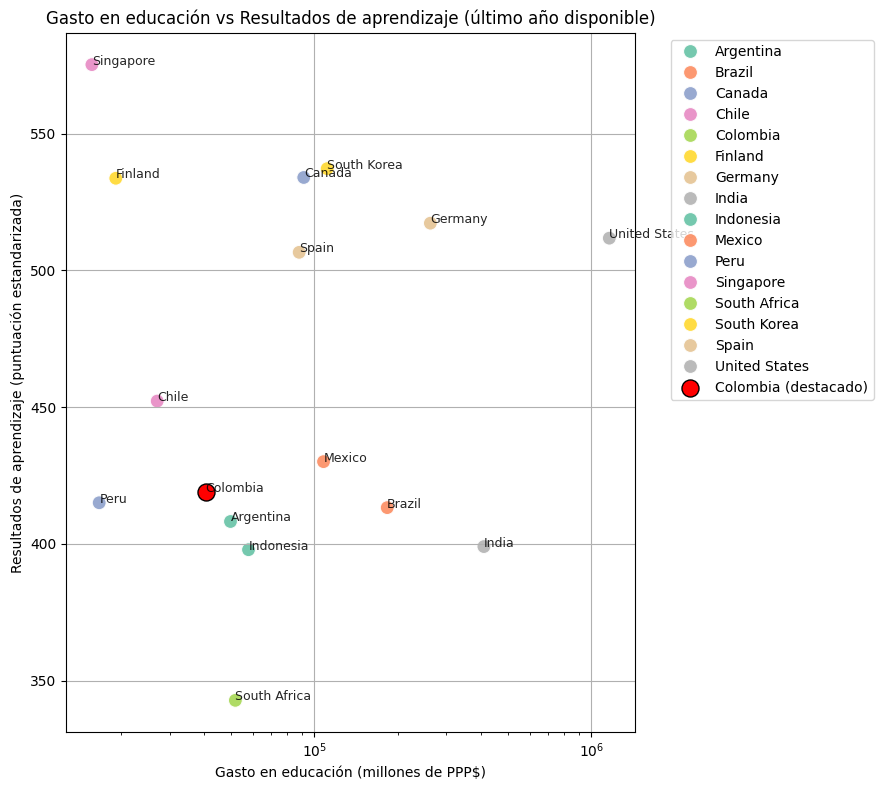

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de países para comparar a Colombia
paises_comparables = [
    'Colombia', 'Argentina', 'Chile', 'Peru', 'Mexico', 'Brazil',        # LATAM
    'India', 'Indonesia', 'Egypt', 'South Africa',                       # Economías similares
    'South Korea', 'Finland', 'Singapore', 'Germany', 'Spain', 'Canada', 'United States' # Benchmark educativos
]

# Filtrar datos válidos
df_clean = df.dropna(subset=[
    'Harmonized test scores',
    'Government expenditure on education, PPP$ (millions)',
    'Year'
])

# Filtrar por países seleccionados
df_clean = df_clean[df_clean['Country'].isin(paises_comparables)]

# Obtener el último año disponible por país
df_latest = df_clean.sort_values('Year').groupby('Country', as_index=False).last()

# Crear el gráfico
plt.figure(figsize=(9, 8))
sns.scatterplot(
    data=df_latest,
    x='Government expenditure on education, PPP$ (millions)',
    y='Harmonized test scores',
    hue='Country',
    palette='Set2',
    s=100,
    alpha=0.9
)

# Escala logarítmica
plt.xscale('log')

# Etiquetas de puntos
for i, row in df_latest.iterrows():
    plt.text(
        row['Government expenditure on education, PPP$ (millions)'] + 30,
        row['Harmonized test scores'],
        row['Country'],
        fontsize=9,
        alpha=0.85
    )

# Destacar a Colombia
col = df_latest[df_latest['Country'] == 'Colombia'].iloc[0]
plt.scatter(
    col['Government expenditure on education, PPP$ (millions)'],
    col['Harmonized test scores'],
    color='red', s=150, edgecolor='black', label='Colombia (destacado)'
)

# Etiquetas y leyenda
plt.xlabel('Gasto en educación (millones de PPP$)')
plt.ylabel('Resultados de aprendizaje (puntuación estandarizada)')
plt.title('Gasto en educación vs Resultados de aprendizaje (último año disponible)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import plotly.express as px

# Filtrar columnas clave
df_filtered = df.dropna(subset=[
    'Harmonized test scores',
    'Government expenditure on education, PPP$ (millions)',
    'Year'
])

# Mantener países comparables
paises = [
    'Colombia', 'Argentina', 'Chile', 'Peru', 'Mexico', 'Brazil',
    'India', 'Indonesia', 'Egypt', 'South Africa',
    'South Korea', 'Finland', 'Singapore', 'Germany', 'Spain', 'Canada', 'United States'
]

df_filtered = df_filtered[df_filtered['Country'].isin(paises)]

df_filtered = df_filtered[
    (df_filtered['Government expenditure on education, PPP$ (millions)'] > 100) &
    (df_filtered['Harmonized test scores'] > 250)
]

# Crear gráfico interactivo
fig = px.scatter(
    df_filtered,
    x='Government expenditure on education, PPP$ (millions)',
    y='Harmonized test scores',
    color='Country',
    animation_frame='Year',
    hover_name='Country',
    size_max=60,
    size=[10]*len(df_filtered),  # opcional para controlar tamaño de puntos
    #log_x=True,
    title='Gasto en educación vs Resultados de aprendizaje por año',
    labels={
        'Government expenditure on education, PPP$ (millions)': 'Gasto (PPP$ millones)',
        'Harmonized test scores': 'Resultados de aprendizaje'
    }
)

fig.update_layout(
    xaxis_title="Gasto en educación (PPP$ millones)",
    yaxis_title="Resultados promedio de aprendizaje",
    legend_title="País",
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()

In [33]:
df[df['Country'] == 'India'][['Year', 'Harmonized test scores', 'Government expenditure on education, PPP$ (millions)']]

,Year,Harmonized test scores,"Government expenditure on education, PPP$ (millions)"
1439,2017,355.0,333026.560
1440,2018,399.0,361183.530
1441,2020,399.0,409602.250
1442,1997,NaN,59065.156
1443,1998,NaN,62776.246
1444,1999,NaN,83311.890
1445,2000,NaN,90072.484
1446,2003,NaN,90304.555
1447,2004,NaN,92154.270
1448,2005,NaN,97136.125
